# Microarray-to-PET: make a reference sheet

In [1]:
import neuromaps.datasets

seroto = neuromaps.datasets.fetch_annotation(source="beliveau2017", space='fsaverage')

/home/yzhou/anaconda3/envs/py311/lib/python3.11/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


[fetch_single_file] Downloading data from 
https://files.osf.io/v1/resources/4mw3a/providers/osfstorage/638543cdc86e2818da88f9e7 ...

[fetch_single_file]  ...done. (1 seconds, 0 min)

[fetch_single_file] Downloading data from 
https://files.osf.io/v1/resources/4mw3a/providers/osfstorage/638543dbc86e2818d988f7ea ...

[fetch_single_file]  ...done. (2 seconds, 0 min)

[fetch_single_file] Downloading data from 
https://files.osf.io/v1/resources/4mw3a/providers/osfstorage/63854385c86e2818da88f94b ...

[fetch_single_file]  ...done. (2 seconds, 0 min)

[fetch_single_file] Downloading data from 
https://files.osf.io/v1/resources/4mw3a/providers/osfstorage/638542b2a98e5f1ac2103866 ...

[fetch_single_file]  ...done. (1 seconds, 0 min)

In [5]:
receptor_names = ['5HT1A', '5HT1B', '5HT2A', '5HT4', '5HTT']
tracer_names = ['cumi101', 'p943', 'cimbi36', 'sb207145', 'dasb']
gene_symbols = ['HTR1A', 'HTR1B', 'HTR2A', 'HTR4', 'SLC6A4']

import pandas as pd

mappings = pd.DataFrame([receptor_names, tracer_names, gene_symbols], index = ['receptor', 'tracer', 'gene']).T

In [3]:
mappings.to_csv('/home/bic/yiguz/projects/beliveau2017_serotonergic_names_mappings.csv')

OSError: Cannot save file into a non-existent directory: '/home/bic/yiguz/projects'

# AHBA Microarray: only keep cortical probes

In [1]:
import abagen
import pandas as pd
import os

os.environ['ABAGEN_DATA'] = "/home/yzhou/projects/interpolate/data/"

datadir = '/home/yzhou/projects/interpolate/data/'

donor_ids = ['10021', '12876', '14380', '15496', '15697', '9861']
cic_ids = ['H0351.1009', 'H0351.1012', 'H0351.1015', 'H0351.1016', 'H0351.2001', 'H0351.2002']

map_to_cic = {'10021': 'H0351.2002', \
              '12876': 'H0351.1009', \
              '14380': 'H0351.1012', \
              '15496': 'H0351.1015', \
              '15697': 'H0351.1016', \
              '9861': 'H0351.2001'}

/home/yzhou/anaconda3/envs/py311/lib/python3.11/site-packages/abagen/mouse/io.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [5]:
for donor_id in donor_ids:
    df0 = pd.read_csv(datadir + f'/cic_coords_microarray/microarray/normalized_microarray_donor{donor_id}/SampleAnnot_original.csv')
    df1 = pd.read_csv(datadir + f'cic_coords_microarray/cic_coords/AllenHumanGeneMNI/transformed-points/{map_to_cic[donor_id]}_SampleAnnot_RAS_mni_nonlin.csv')

    df0['mni_x'] = df1['mni_nlin_x']
    df0['mni_y'] = df1['mni_nlin_y']
    df0['mni_z'] = df1['mni_nlin_z']

    df0[ df0['slab_type'] == 'CX' ].to_csv(datadir + f'/cic_coords_microarray/microarray/normalized_microarray_donor{donor_id}/SampleAnnot.csv')

In [23]:
import abagen
import os

os.environ['ABAGEN_DATA'] = '/home/yzhou/projects/interpolate/data/cic_coords_microarray/'
e, m = abagen.get_samples_in_mask(mask=None, \
                                  corrected_mni=False, \
                                  lr_mirror = None, \
                                  data_dir = '/home/yzhou/projects/interpolate/data/cic_coords_microarray/microarray/',\
                                  ibf_threshold=0.1)

{'9861': '/home/yzhou/projects/interpolate/data/cic_coords_microarray/microarray/normalized_microarray_donor9861/SampleAnnot.csv', '10021': '/home/yzhou/projects/interpolate/data/cic_coords_microarray/microarray/normalized_microarray_donor10021/SampleAnnot.csv', '12876': '/home/yzhou/projects/interpolate/data/cic_coords_microarray/microarray/normalized_microarray_donor12876/SampleAnnot.csv', '14380': '/home/yzhou/projects/interpolate/data/cic_coords_microarray/microarray/normalized_microarray_donor14380/SampleAnnot.csv', '15496': '/home/yzhou/projects/interpolate/data/cic_coords_microarray/microarray/normalized_microarray_donor15496/SampleAnnot.csv', '15697': '/home/yzhou/projects/interpolate/data/cic_coords_microarray/microarray/normalized_microarray_donor15697/SampleAnnot.csv'}
                   x          y          z
594         5.655803 -26.155168  51.384257
2985       29.543445  17.026195  -6.486713
2801       29.696883 -19.278341  15.007620
2273      -26.031307 -20.993209  -0.2

In [29]:
left_probes_ind = np.where( m.to_numpy()[:, 0] < 0 )[0]

In [36]:
left_probes_ind.shape

(2013,)

In [39]:
left_gene_expr = e.loc[m.index[left_probes_ind]]
left_mni_coords = m.loc[m.index[left_probes_ind]]

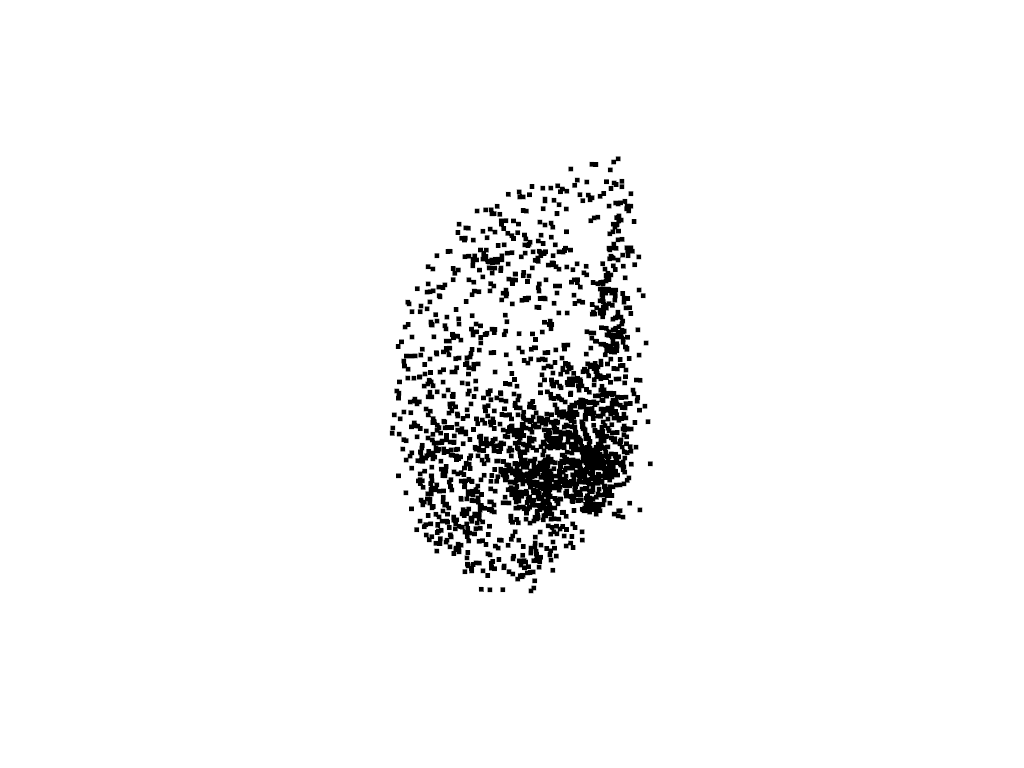

In [40]:
import pyvista as pv
import numpy as np
pl = pv.Plotter()

pl.add_points(m.to_numpy()[left_probes_ind], color = 'k')
pl.camera_position = 'xz'
pl.show(jupyter_backend='static')

In [41]:
import joblib

joblib.dump((left_gene_expr, left_mni_coords), '/home/yzhou/gitrepo/interpolate/data/abagen_get_samples_in_mask_left-cx_ibf-01_coords-cic.pkl')

['/home/yzhou/gitrepo/interpolate/data/abagen_get_samples_in_mask_left-cx_ibf-01_coords-cic.pkl']

# load abagen data

In [22]:
e,m = joblib.load('/home/yzhou/gitrepo/interpolate/data/abagen_get_samples_in_mask_ibf-01_coords-cic.pkl')

In [23]:
# initiate a new dataframe to compile the expressions and then save it

serotonergic = pd.DataFrame([None])

for gene_symbol in gene_symbols:

    if serotonergic.empty: serotonergic = e[gene_symbol]
    else: serotonergic = pd.concat([ serotonergic, e[gene_symbol] ], axis = 1)

serotonergic = serotonergic.drop(0, axis = 0)
serotonergic = serotonergic.drop(0, axis = 1)

In [24]:
serotonergic

,HTR1A,HTR1B,HTR2A,HTR4,SLC6A4
594,0.535725,0.626895,0.820328,0.614966,0.069582
2985,0.582408,0.740827,0.744289,0.561485,0.377521
2801,0.444434,0.617993,0.358410,0.183968,0.896657
2273,0.153231,0.707619,0.151277,0.119202,0.692482
2785,0.529715,0.454390,0.375179,0.717376,0.594159
...,...,...,...,...,...
159439039,0.492662,0.908513,0.376610,0.567687,0.074533
159438991,0.132141,1.000000,0.478848,0.135214,0.511235
159438975,0.116330,0.183857,0.456828,0.030026,0.750181
159438959,0.064028,0.176525,0.353386,0.201005,0.105511


In [25]:
joblib.dump((serotonergic,m), '/home/yzhou/gitrepo/interpolate/data/abagen_ibf-01_serotonergic_gene_expression.pkl')

['/home/yzhou/gitrepo/interpolate/data/abagen_ibf-01_serotonergic_gene_expression.pkl']

# Set up src_polydata that contains genes to interpolate and covariate PET maps sampled at the same coordinates

In [26]:
import joblib
import pyvista as pv

e,m = joblib.load('/home/yzhou/gitrepo/interpolate/data/abagen_ibf-01_serotonergic_gene_expression.pkl')


In [27]:
microarray = pv.PolyData(m.to_numpy())
for gene_symbol in gene_symbols:
    microarray['mrna_' + gene_symbol] = e[gene_symbol]

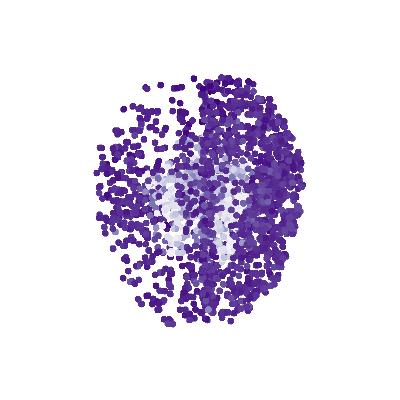

In [28]:
pl = pv.Plotter(lighting = 'three lights', window_size = (400,400))

points_aes = {"show_scalar_bar": False,\
            "render_points_as_spheres": True,\
            "point_size": 7,\
            "specular": 0, "diffuse":0, "ambient":1}

pl.add_points(microarray.rotate_z(180), cmap = 'Purples', scalars = 'mrna_HTR2A', **points_aes)
pl.camera_position = 'xy'
pl.show(jupyter_backend = 'static')

In [29]:
import joblib
import nibabel as nb
from nibabel.affines import apply_affine
import numpy as np
import numpy.linalg as npl
import os
from scipy.ndimage import map_coordinates

reregistered_pet_dir = '/home/yzhou/projects/out_2009c/'

fnames = os.listdir(reregistered_pet_dir)

for fname in fnames:
    PET = nb.load(reregistered_pet_dir + fname)

    sourcetag = fname.split('_')[0].split('-')[1]
    desctag = fname.split('_')[1].split('-')[1]

    maptag = f'pet_{sourcetag}_{desctag}'

    points = microarray.points
    img_data = PET.get_fdata()
    inverse_aff = npl.inv(PET.affine)
    ijk_points = apply_affine(inverse_aff, points)

    vals = np.zeros(microarray.n_points)
    for pi in range(points.shape[0]):
        
        vox_value = map_coordinates(img_data, ijk_points[pi,:].reshape(-1,1), order=1)
        vals[pi] = vox_value[0]
        
    microarray[maptag] = vals

In [30]:
joblib.dump(microarray, '/home/yzhou/gitrepo/interpolate/data/icbm09c_cic-volume_microarray-pet.pkl')

['/home/yzhou/gitrepo/interpolate/data/icbm09c_cic-volume_microarray-pet.pkl']

## load interpolated maps and compare with PET


In [4]:
import joblib
projdir = '/home/yzhou/gitrepo/interpolate/'

probes = joblib.load( projdir + '/data/icbm09c_left-volume_microarray-pet.pkl' )

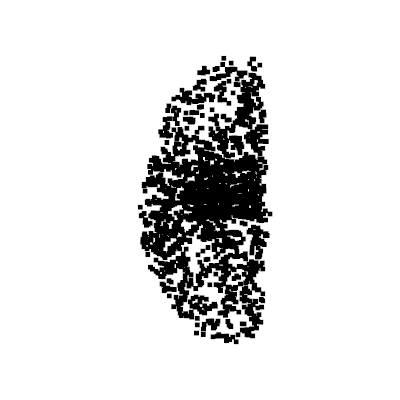

In [7]:
import pyvista as pv
pl = pv.Plotter(window_size = (400,400))

pl.add_points(probes, color = 'k')
pl.camera_position = 'xy'
pl.show(jupyter_backend = 'static')

In [8]:
import pandas as pd

mappings = pd.read_csv(projdir + '/data/beliveau2017_serotonergic_names_mappings.csv')

In [9]:
mappings[ mappings['gene'] == 'HTR1A' ] ['tracer'].item()

'cumi101'

In [11]:
res.keys()

dict_keys(['voronoi', 'variogram', 'determ_params', 'interpolated', 'performance', 'interpolant_labels'])

                          idw        knn        rbf        swr       krige  \
pearson              0.726758   0.786791   0.772887  -0.017895    0.772502   
spearman             0.725016   0.800049   0.791120   0.054748    0.766466   
ssim                 0.083788   0.083539   0.083470   0.081304    0.083560   
r2                 -10.830489 -10.834578 -10.835651 -10.893350  -10.835119   
rmse                32.045673  32.051208  32.052662  32.130695   32.051941   
kolmogorov_smirnov   1.000000   1.000000   1.000000   1.000000    1.000000   
jensen_shannon       0.007908   0.006415   0.006707   0.042355    0.006856   
run_time             0.352838   0.047026   0.903168  80.224097  195.521143   

                       regkrige  
pearson                0.734977  
spearman               0.725112  
ssim                   0.083853  
r2                   -10.831150  
rmse                  32.046566  
kolmogorov_smirnov     1.000000  
jensen_shannon         0.007571  
run_time            1613.

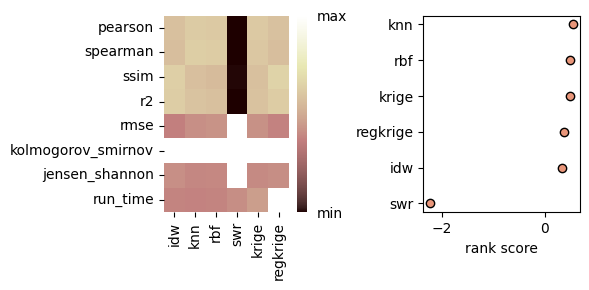

Maximum number of clients reached


(3599,)
3599


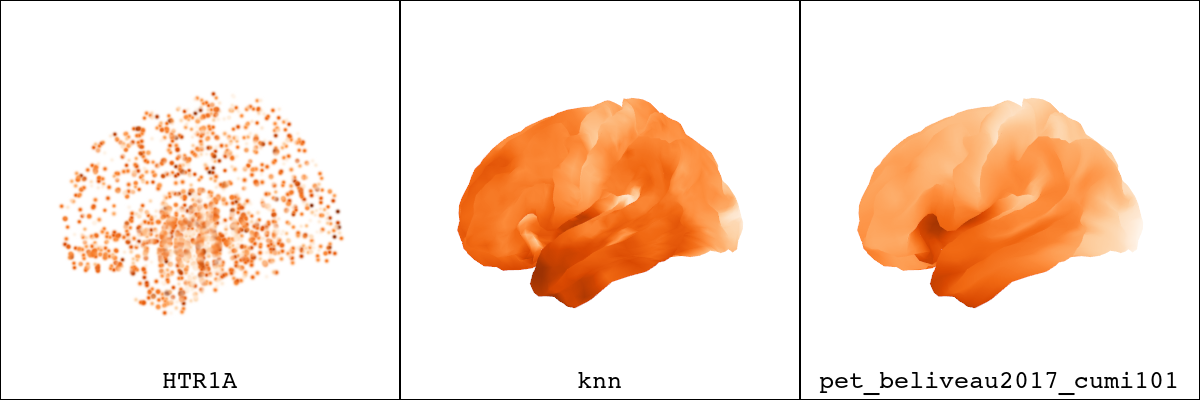

                          idw        knn        rbf        swr  krige  \
pearson              0.176962   0.298996   0.303333   0.328743    NaN   
spearman             0.159223   0.246838   0.255846   0.134702    NaN   
ssim                 0.139165   0.139336   0.139353   0.139711    NaN   
r2                 -31.836481 -31.830364 -31.830183 -31.838402    NaN   
rmse                20.272547  20.270658  20.270603  20.273140    NaN   
kolmogorov_smirnov   1.000000   1.000000   1.000000   1.000000    NaN   
jensen_shannon       0.029478   0.010417   0.010009   0.005400    NaN   
run_time             0.277951   0.013179   0.497979  80.942017    NaN   

                    regkrige  
pearson                  NaN  
spearman                 NaN  
ssim                     NaN  
r2                       NaN  
rmse                     NaN  
kolmogorov_smirnov       NaN  
jensen_shannon           NaN  
run_time                 NaN  
['idw5', 'knn11', 'rbf10gaussian']


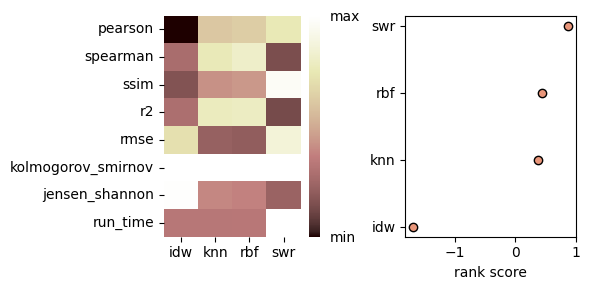

(3599,)
3599


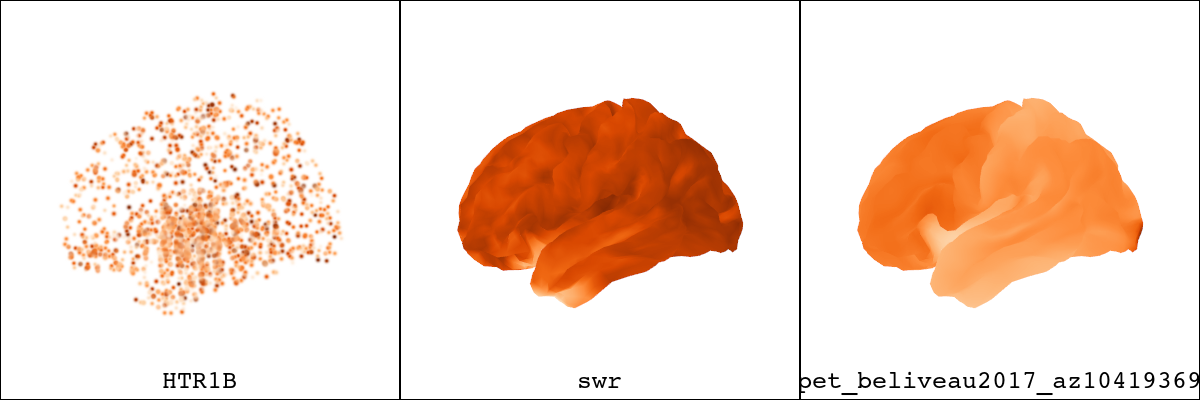

                          idw        knn        rbf        swr       krige  \
pearson              0.243301   0.331933   0.323572   0.340224    0.319152   
spearman             0.180032   0.322552   0.320371   0.378682    0.264088   
ssim                 0.046257   0.046006   0.045963   0.042458    0.046026   
r2                 -37.350357 -37.358646 -37.360180 -37.484493  -37.358582   
rmse                52.383717  52.389374  52.390423  52.475246   52.389332   
kolmogorov_smirnov   1.000000   1.000000   1.000000   1.000000    1.000000   
jensen_shannon       0.005395   0.004862   0.004972   0.010160    0.004860   
run_time             0.334492   0.038346   0.521648  79.306580  186.352225   

                       regkrige  
pearson                0.252502  
spearman               0.208733  
ssim                   0.044734  
r2                   -37.404202  
rmse                  52.420475  
kolmogorov_smirnov     1.000000  
jensen_shannon         0.007648  
run_time            1627.

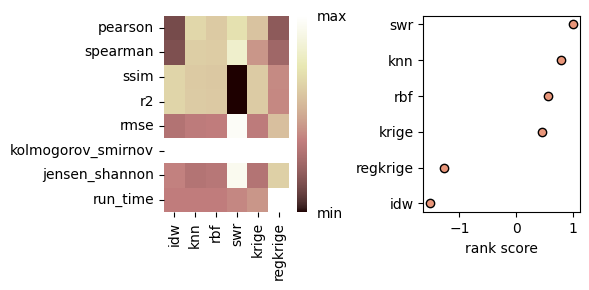

(3599,)
3599


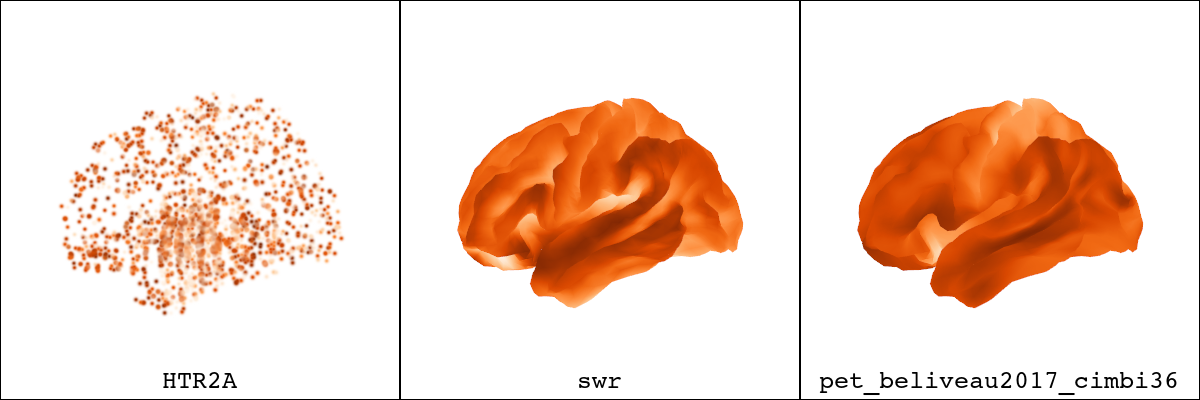

                          idw        knn        rbf        swr       krige  \
pearson              0.337262   0.450838   0.442601   0.145760    0.359766   
spearman             0.332969   0.474840   0.471090   0.149262    0.361260   
ssim                 0.946773   0.946782   0.946768   0.943456    0.946793   
r2                 -16.030890 -16.019588 -16.024477 -17.070696  -16.021797   
rmse                 1.636888   1.636345   1.636580   1.686117    1.636451   
kolmogorov_smirnov   1.000000   1.000000   1.000000   1.000000    1.000000   
jensen_shannon       0.006887   0.005477   0.005567   0.026691    0.006263   
run_time             0.318337   0.015574   0.613703  83.022646  203.044956   

                       regkrige  
pearson                0.351211  
spearman               0.338819  
ssim                   0.947316  
r2                   -15.859928  
rmse                   1.628651  
kolmogorov_smirnov     1.000000  
jensen_shannon         0.006474  
run_time            1624.

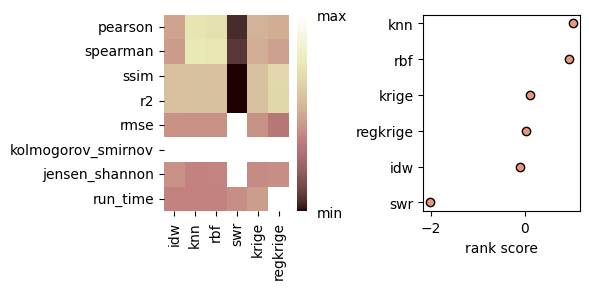

(3599,)
3599


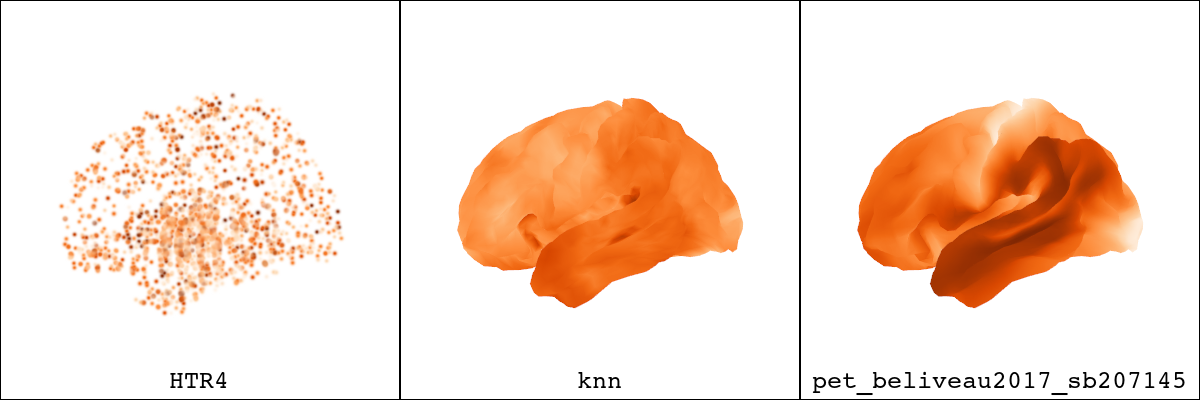

                         idw       knn       rbf        swr  krige  regkrige
pearson             0.102042  0.196092  0.203368   0.395256    NaN       NaN
spearman            0.150721  0.209071  0.216180   0.241692    NaN       NaN
ssim                0.710202  0.709959  0.710016   0.707909    NaN       NaN
r2                 -8.780540 -8.780500 -8.778686  -8.839811    NaN       NaN
rmse                4.722643  4.722633  4.722195   4.736931    NaN       NaN
kolmogorov_smirnov  1.000000  1.000000  1.000000   1.000000    NaN       NaN
jensen_shannon      0.020455  0.018093  0.017542   0.012915    NaN       NaN
run_time            0.321838  0.050273  0.830157  79.085098    NaN       NaN
['idw3', 'knn14', 'rbf13gaussian']


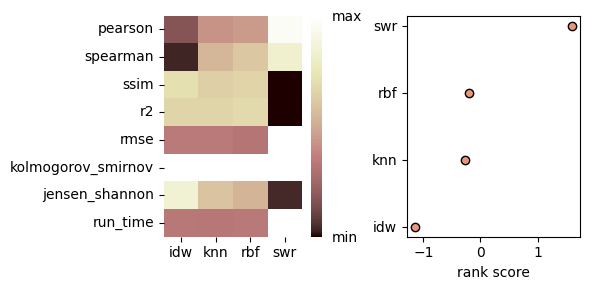

(3599,)
3599


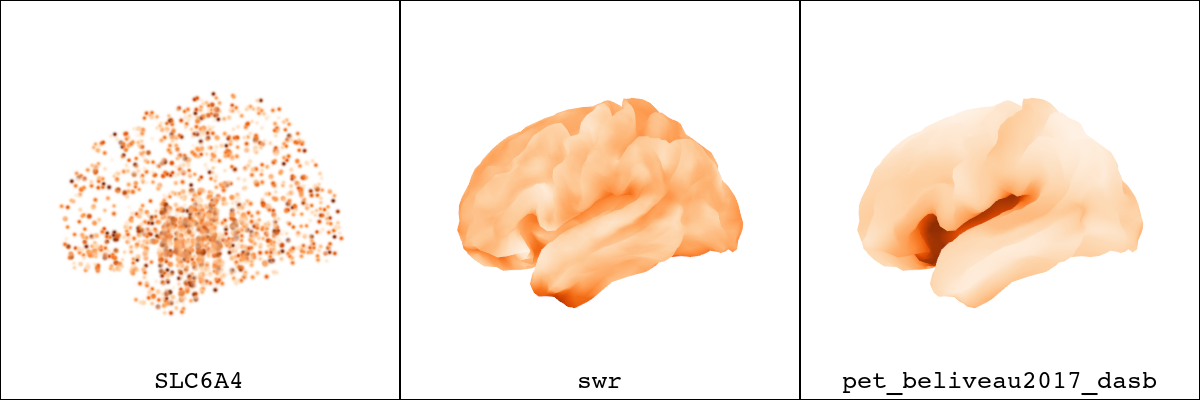

In [14]:
import joblib
from scipy.stats import zscore

compare = joblib.load(projdir + '/data/fsLR-4k_reduced-midthickness_beliveau.pkl')

for gene in mappings['gene']:

    res = joblib.load(projdir + f'/results/genes/fsLR-4k_mrna_{gene}_volume_microarray-pet_samp-all_pct-100_0_all_info.pkl')

    # scale evenly for visualization
    perf = res['performance'][0].dropna(axis=1)
    perf = zscore( perf, axis = 1 )
    print(res['performance'][0])
    print(res['interpolant_labels'])
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns
    
    fig, axs = plt.subplots(1,2, figsize = (6,3))
    
    axs[0] = sns.heatmap( perf, cmap = 'pink', ax=axs[0])
    cbar = axs[0].collections[0].colorbar
    cbar.ax.tick_params(left=False, right=False, labelleft=False)
    vmin = np.nanmin(perf)
    vmax = np.nanmax(perf)
    # Set ticks at min and max
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels(["min", "max"])
    
    
    ranks = perf.loc['pearson'].sort_values()
    axs[1].scatter(ranks, ranks.index, color = 'darksalmon', edgecolor = 'k')
    axs[1].set_xlabel('rank score')
    
    plt.tight_layout()
    plt.show()

    import pyvista as pv

    mesh_aes = {"show_scalar_bar": False,\
                "smooth_shading": True,\
                "specular": 0, "diffuse":0, "ambient":1}
    
    pl = pv.Plotter(shape = (1,3), window_size = (1200,400))

    approach = ranks.index[-1]
    compare_maptag = 'pet_beliveau2017_' + mappings[ mappings['gene'] == gene ] ['tracer'].item()

    pl.subplot(0,0)
    pl.add_points(probes.rotate_z(180), scalars = probes['mrna_' + gene ], \
                  style = 'points_gaussian', cmap = 'Oranges', show_scalar_bar = False)
    pl.add_text(gene, position = 'lower_edge', font = 'courier', font_size = 10)
    pl.camera_position = 'yz'
    
    pl.subplot(0,1)
    print(res['interpolated'][approach].shape)
    print(compare.n_points)
    pl.add_mesh(compare.rotate_z(180), scalars = res['interpolated'][approach], cmap = 'Oranges', **mesh_aes)
    pl.add_text(approach, position = 'lower_edge', font = 'courier', font_size = 10)
    pl.camera_position = 'yz'
    
    pl.subplot(0,2)
    pl.add_mesh(compare.rotate_z(180), scalars = compare_maptag, cmap = 'Oranges', **mesh_aes)
    pl.add_text(compare_maptag, position = 'lower_edge', font = 'courier', font_size = 10)
    pl.camera_position = 'yz'
    pl.show(jupyter_backend = 'static')